In [1]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import h5py
import argparse
import numpy as np
from os.path import exists
import seaborn as sns
from h5_util import SurfaceFileHandler
import matplotlib 
from scipy.interpolate import RegularGridInterpolator

In [2]:
#surf_file = "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/vox1_v1/19-01T23-01-23/26-01T02-52-50/30-01T22-14-28/31-01T00-59-11/surface_[-2.08,2.08,101]x[-2.08,2.08,101].hdf5"

# surf_file = "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s/20-03T17-26-23/surface_[-0.5,0.5,10]x[-0.5,0.5,10].h5"

surf_file = "/mnt/ssd2/Tassi/TassiMA/loss-landscape/Output/res2net8s_train/13-06T11-39-49/surface_[-0.95,1.05,21]x[-0.95,1.05,21].h5"

In [3]:
SF = SurfaceFileHandler(surf_file)

In [4]:
SF.getTrainLoss_byCoords(0,0.)

0  not in  x  coordinates
Closest value is  -0.05555555555555558
0.0  not in  y  coordinates
Closest value is  -0.05555555555555558


812.0656471789723

In [5]:
SF.getTrainAcc_byCoords(0,0.)

0  not in  x  coordinates
Closest value is  -0.05555555555555558
0.0  not in  y  coordinates
Closest value is  -0.05555555555555558


0.0

In [5]:
surf_name = "train_loss"

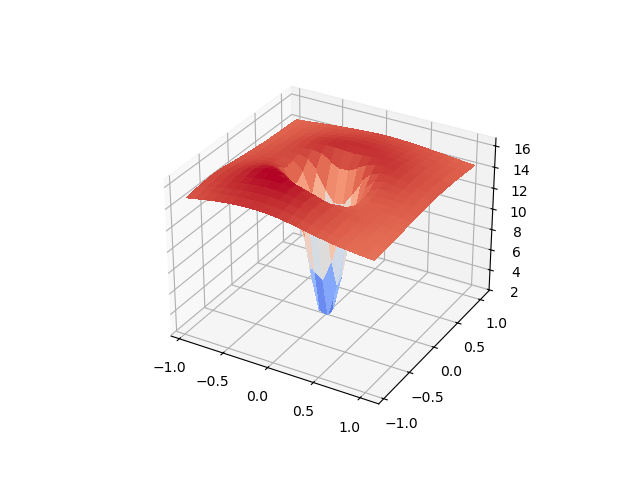

In [6]:

%matplotlib widget
f = h5py.File(surf_file, 'r')
x = np.array(f['xcoordinates'][:])
y = np.array(f['ycoordinates'][:])
X, Y = np.meshgrid(x, y)

if surf_name in f.keys():
    Z = np.array(f[surf_name][:])
elif surf_name == 'train_err' or surf_name == 'test_err' :
    Z = 100 - np.array(f[surf_name][:])
else:
    print ('%s is not found in %s' % (surf_name, surf_file))
# --------------------------------------------------------------------
# Plot 3D surface
# --------------------------------------------------------------------
fig = plt.figure()
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
# fig.colorbar(surf, shrink=0.5, aspect=5)
# fig.savefig(".".join(surf_file.split(".")[:-1]) + '_' + surf_name + '_3dsurface.pdf', dpi=300,
#             bbox_inches='tight', format='pdf')

plt.show()

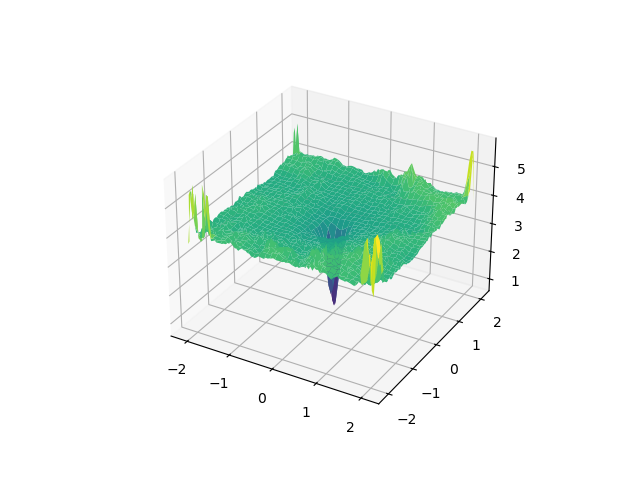

In [11]:
fig = plt.figure()
ax = plt.axes(projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=True)
plt.show()

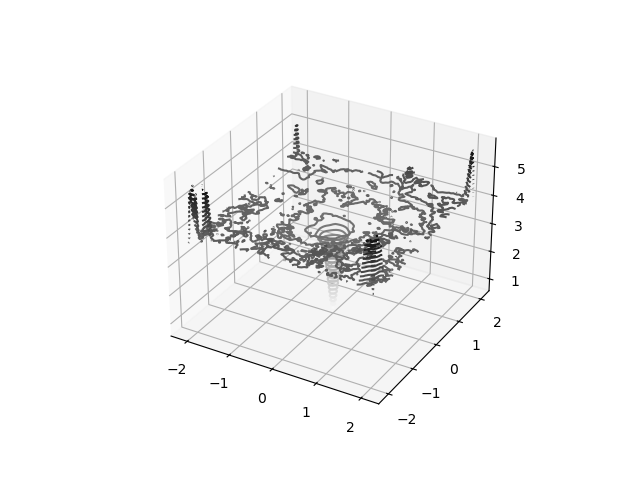

In [12]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X, Y, Z, 50, cmap='binary')
plt.show()

In [50]:
add_points = 2
spacing = X[0,1] - X[0,0] 
new_spacing = spacing/add_points
x_new=np.arange(X[0,0]+new_spacing,X[-1,-1]-new_spacing,new_spacing)
y_new=np.arange(Y[0,0]+new_spacing,Y[-1,-1]-new_spacing,new_spacing)
grid_new = np.meshgrid(x_new, y_new)
grid_flattened = np.transpose(np.array([k.flatten() for k in grid_new]))

#Interpolation onto a finer grid
grid_interpol = RegularGridInterpolator(grid_old,vel,method='linear')
vel_interpol = grid_interpol(grid_flattened)

In [51]:
y_new

array([-2.06250000e+00, -2.04166667e+00, -2.02083333e+00, -2.00000000e+00,
       -1.97916667e+00, -1.95833333e+00, -1.93750000e+00, -1.91666667e+00,
       -1.89583333e+00, -1.87500000e+00, -1.85416667e+00, -1.83333333e+00,
       -1.81250000e+00, -1.79166667e+00, -1.77083333e+00, -1.75000000e+00,
       -1.72916667e+00, -1.70833333e+00, -1.68750000e+00, -1.66666667e+00,
       -1.64583333e+00, -1.62500000e+00, -1.60416667e+00, -1.58333333e+00,
       -1.56250000e+00, -1.54166667e+00, -1.52083333e+00, -1.50000000e+00,
       -1.47916667e+00, -1.45833333e+00, -1.43750000e+00, -1.41666667e+00,
       -1.39583333e+00, -1.37500000e+00, -1.35416667e+00, -1.33333333e+00,
       -1.31250000e+00, -1.29166667e+00, -1.27083333e+00, -1.25000000e+00,
       -1.22916667e+00, -1.20833333e+00, -1.18750000e+00, -1.16666667e+00,
       -1.14583333e+00, -1.12500000e+00, -1.10416667e+00, -1.08333333e+00,
       -1.06250000e+00, -1.04166667e+00, -1.02083333e+00, -1.00000000e+00,
       -9.79166667e-01, -

In [43]:
X[0:]

array([[-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333],
       [-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333],
       [-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333],
       ...,
       [-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333],
       [-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333],
       [-2.08333333, -2.04166667, -2.        , ...,  2.        ,
         2.04166667,  2.08333333]])

In [40]:
X[0,0]+spacing

np.float64(-2.041666666666665)

In [44]:
new_spacing

np.float64(0.02083333333333348)